# Chapter 20: QAOA

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [1]:
# Setup and imports
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler


### QAOA Concept

In [2]:

H_C = np.array([
    [0, 0,  0, 0],
    [0, 0,  0, 0],
    [0, 0, -1, 0],
    [0, 0,  0, 1],
], dtype=float)

# eigh returns eigenvalues in ascending order (exploits Hermitian symmetry)
eigvals, eigvecs = np.linalg.eigh(H_C)

ground_energy = eigvals[0]
ground_state  = eigvecs[:, 0]

# Interpret the basis index as a 2-qubit bitstring |q1 q0>
n_qubits = int(np.log2(H_C.shape[0]))
idx      = int(np.argmax(np.abs(ground_state)))
bitstring = format(idx, f"0{n_qubits}b")

print(f"Ground-state energy : {ground_energy}")
print(f"Ground-state vector : {ground_state}")
print(f"Bitstring |q1 q0>   : |{bitstring}>")
print(f"=> q1 = {bitstring[0]}, q0 = {bitstring[1]}")

Ground-state energy : -1.0
Ground-state vector : [0. 0. 1. 0.]
Bitstring |q1 q0>   : |10>
=> q1 = 1, q0 = 0


## Example 2

In [3]:
import numpy as np
from functools import reduce

# ---------------------------------------------------------------
# Approach 1: Explicit construction via Kronecker products + eigh
# Pedagogical but O(8^3) in memory; fine for 3 qubits, useless for many.
# ---------------------------------------------------------------
I = np.eye(2)
Z = np.array([[1, 0], [0, -1]])
def kron(*ops):
    """
    Tensor (Kronecker) product of an arbitrary number of operators.

    Left-folds ``numpy.kron`` over the given operators so that the leftmost
    argument acts on the highest-index qubit and the rightmost on qubit 0,
    building the full multi-qubit operator (e.g. Z ⊗ Z ⊗ I) used to assemble
    the QAOA cost Hamiltonian.

    Parameters
    ----------
    *ops : numpy.ndarray
        One or more square matrices (typically 2×2 single-qubit operators),
        ordered from the most-significant qubit to the least-significant.

    Returns
    -------
    numpy.ndarray
        The Kronecker product of all inputs; for n single-qubit 2×2 factors
        this is a (2**n, 2**n) matrix.
    """
    return reduce(np.kron, ops)

# Convention: leftmost factor acts on qubit 2, rightmost on qubit 0
H_C = ( 0.0075 * kron(Z, Z, I)
      + 0.0500 * kron(Z, I, Z)
      + 0.1500 * kron(I, Z, Z)
      + 0.0425 * kron(Z, I, I)
      + 0.0925 * kron(I, Z, I)
      - 0.1500 * kron(I, I, Z)
      - 0.1925 * kron(I, I, I) )
eigvals, eigvecs = np.linalg.eigh(H_C)
idx = int(np.argmax(np.abs(eigvecs[:, 0])))
print(f"[dense]  E0 = {eigvals[0]:.4f},  |q2 q1 q0> = |{idx:03b}>")

# ---------------------------------------------------------------
# Approach 2: Diagonal-only — H_C is diagonal in the computational basis,
# so never materialize the 8x8 matrix. This is O(2^n) memory, not O(4^n).
# ---------------------------------------------------------------
n = 3
# Bit vectors for all 2^n basis states: rows indexed by integer i = q2 q1 q0
bits = ((np.arange(2**n)[:, None] >> np.arange(n-1, -1, -1)) & 1)  # shape (8, 3)
# Z eigenvalue on qubit k for state i is (-1)^{bits[i,k]} = 1 - 2*bits[i,k]
sgn = 1 - 2 * bits       # +1 for q=0, -1 for q=1

diag = ( 0.0075 * sgn[:, 0] * sgn[:, 1]                 # Z2 Z1
       + 0.0500 * sgn[:, 0] * sgn[:, 2]                 # Z2 Z0
       + 0.1500 * sgn[:, 1] * sgn[:, 2]                 # Z1 Z0
       + 0.0425 * sgn[:, 0]                             # Z2
       + 0.0925 * sgn[:, 1]                             # Z1
       - 0.1500 * sgn[:, 2]                             # Z0
       - 0.1925 )                                       # I

i_min = int(np.argmin(diag))
print(f"[diag]   E0 = {diag[i_min]:.4f},  |q2 q1 q0> = |{i_min:03b}>")

# ---------------------------------------------------------------
# Approach 3: Direct QUBO evaluation (skip the Hamiltonian entirely).
# This is what you should *actually* do for any QUBO that fits in memory.
# ---------------------------------------------------------------
a, b, c = bits[:, 2], bits[:, 1], bits[:, 0]   # a = q0, b = q1, c = q2
f = 0.6*a*b + 0.2*a*c + 0.03*b*c - 0.1*a - 0.5*b - 0.2*c
i_min = int(np.argmin(f))
print(f"[qubo]   f* = {f[i_min]:.4f},  (a,b,c) = "
      f"({a[i_min]}, {b[i_min]}, {c[i_min]})")

[dense]  E0 = -0.6700,  |q2 q1 q0> = |110>
[diag]   E0 = -0.6700,  |q2 q1 q0> = |110>
[qubo]   f* = -0.6700,  (a,b,c) = (0, 1, 1)


## Simple unconstrained QUBO

c:\Users\ksure\anaconda3\envs\quantumTest\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\ksure\anaconda3\envs\quantumTest\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


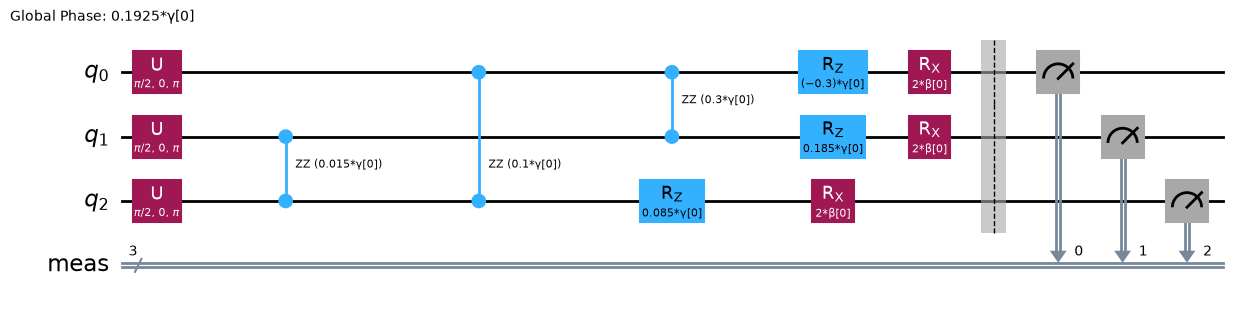

Optimal bitstring: 110
Optimal solution: a=0, b=1, c=1
QUBO value: -0.6699999999999999


In [4]:
# QUBO: minimize 0.6ab + 0.2ac + 0.03bc - 0.1a - 0.5b - 0.2c
# Define cost Hamiltonian from QUBO
# After variable substitution x = (1-Z)/2
# H_C = 0.15 Z_0Z_1 + 0.05 Z_0Z_2 + 0.0075 Z_1Z_2 + h_0 Z_0 + h_1 Z_1 + h_2 Z_2 + C
cost_hamiltonian = SparsePauliOp.from_list([
    ("ZZI", 0.0075),   # Z2 * Z1 * I
    ("ZIZ", 0.05),     # Z2 * I * Z0
    ("IZZ", 0.15),     # I * Z1 * Z0
    ("ZII", 0.0425),   # h2 (Z2)
    ("IZI", 0.0925),   # h1 (Z1)
    ("IIZ", -0.1500),  # h0 (Z0)
    ("III", -0.1925)   # Constant Offset C
])
qaoa = QAOA(
    sampler=StatevectorSampler(), # uses noiseless statevector simulator
    optimizer=COBYLA(maxiter=300),
    reps = 1
)

result = qaoa.compute_minimum_eigenvalue(cost_hamiltonian)

optimal_circuit = result.optimal_circuit
display(optimal_circuit.decompose(reps=2).draw('mpl'))

# Extract optimal solution
optimal_bitstring = max(result.eigenstate, key=result.eigenstate.get)
print(f"Optimal bitstring: {optimal_bitstring}")
c,b,a = [int(bit) for bit in optimal_bitstring]

print(f"Optimal solution: a={a}, b={b}, c={c}")

# Verify with classical QUBO evaluation
qubo_value = 0.6*a*b + 0.2*a*c + 0.03*b*c - 0.1*a - 0.5*b - 0.2*c
print(f"QUBO value: {qubo_value}")

## Max-Cut with Constraints

In [5]:
"""
MAX-CUT QAOA with Constrained Mixer
====================================
Graph: 5 nodes with edges: (1,2), (1,3), (2,4), (3,4), (3,5), (4,5)
Constraint: Nodes 1 and 4 must be in DIFFERENT sets  q_0 + q_3 = 1

Convert to Hamiltonian:
minimize H_C = 0.5 * sum_{(i,j) in E} Z_i*Z_j
# Pauli convention: rightmost = qubit 0, leftmost = qubit 4
"""

cost_hamiltonian = SparsePauliOp.from_list([
    ("IIIZZ", 0.5),   # Z_0*Z_1 -- edge (1,2)
    ("IIZIZ", 0.5),   # Z_0*Z_2 -- edge (1,3)
    ("IZIZI", 0.5),   # Z_1*Z_3 -- edge (2,4)
    ("IZZII", 0.5),   # Z_2*Z_3 -- edge (3,4)
    ("ZIZII", 0.5),   # Z_2*Z_4 -- edge (3,5)
    ("ZZIII", 0.5),   # Z_3*Z_4 -- edge (4,5)
])

# ============================================================================
# Define Constrained Mixer: Preserves q_0 + q_3 = 1
# ============================================================================
# XY mixer for qubits 0 and 3 (nodes 1 and 4)
# Standard X mixer for qubits 1, 2, 4 (nodes 2, 3, 5)

mixer_hamiltonian = SparsePauliOp.from_list([
    ("IXIIX", 0.5),   # X_0*X_3 (XY mixer component)
    ("IYIIY", 0.5),   # Y_0*Y_3 (XY mixer component)
    ("IIIXI", 1.0),   # X_1 (standard mixer)
    ("IIXII", 1.0),   # X_2 (standard mixer)
    ("XIIII", 1.0),   # X_4 (standard mixer)
])

initial_state = QuantumCircuit(5)
initial_state.x(0)  # q_0=1, satisfies constraint q_0 + q_3 = 1
initial_state.h([1, 2, 4])  # Superposition on unconstrained qubits

qaoa = QAOA(
    sampler=StatevectorSampler(),
    optimizer=COBYLA(maxiter=200),
    initial_state=initial_state,
    mixer=mixer_hamiltonian,
    reps=1
)

result = qaoa.compute_minimum_eigenvalue(cost_hamiltonian)

optimal_bitstring = max(result.eigenstate, key=result.eigenstate.get)
q4, q3, q2, q1, q0 = [int(bit) for bit in optimal_bitstring]

print(f"Optimal bitstring: |{optimal_bitstring}>")

q_vec = np.array([q0, q1, q2, q3, q4])
cut_edges = []

indexed = [(1,2), (1,3), (2,4), (3,4), (3,5), (4,5)]
edges = [(i-1, j-1) for i, j in indexed]
for i, j in edges:
    if q_vec[i] != q_vec[j]:
        cut_edges.append((i+1, j+1))

print(f"Cut value: {len(cut_edges)}")
print(f"Constraint check: q_0 + q_3  = {q0+q3} ")


c:\Users\ksure\anaconda3\envs\quantumTest\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\ksure\anaconda3\envs\quantumTest\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\ksure\anaconda3\envs\quantumTest\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Optimal bitstring: |10011>
Cut value: 4
Constraint check: q_0 + q_3  = 1 
